# 02. Preprocessing & Target Engineering

**ColoGrowth-ML: Cross-Platform Calibration Benchmark for Colon Cancer Proliferation Classification**

Transform raw transcriptomic data into a leakage-free feature matrix for ML training.

### ISEF Key Design: Dual Leakage Prevention
- **Target leakage**: 10 proliferation genes removed from features (they define the target, so keeping them would leak the answer)
- **Data leakage**: All preprocessing encapsulated inside sklearn Pipeline so scaling/selection parameters are computed fold-locally

In [1]:
import os, sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocess import (
    compute_proliferation_score,
    binarize_target, remove_proliferation_genes, PROLIF_GENES, preprocess_and_save_data
)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


---
## Step 1: Compute Proliferation Signature Score

The **target** is the mean z-score of 10 well-known cell-cycle genes. This gives a continuous proliferation index, binarized at the median.

### Why these 10 genes?
They are core cell-cycle regulators validated across cancer types in TCGA (Whitfield et al., Mol Biol Cell 2002). MKI67 (Ki-67) is the clinical gold standard for proliferation assessment.

In [2]:
# Load real processed data if available, else synthetic
processed_dir = '../data/processed'
if os.path.exists(os.path.join(processed_dir, 'geo_X_features.csv')):
    print('Loading real GEO data from data/processed/')
    X = pd.read_csv(os.path.join(processed_dir, 'geo_X_features.csv'), index_col=0)
    scores = pd.read_csv(os.path.join(processed_dir, 'geo_proliferation_scores.csv'), index_col=0)
    scores = scores.iloc[:, 0] if scores.shape[1] >= 1 else scores
    clinical_df = pd.read_csv(os.path.join(processed_dir, 'geo_clinical.csv'), index_col=0)
    clinical_df = clinical_df.rename(columns={"age.at.diagnosis_(year)": "age", "sex": "gender", "tnm.stage": "stage", "os.event": "os_event", "os.delay_(months)": "os_time", "rfs.event": "rfs_event", "rfs.delay": "rfs_time"})
    clinical_df["stage"] = clinical_df["stage"].map({1: "Stage I", 2: "Stage II", 3: "Stage III", 4: "Stage IV"})
    clinical = clinical_df  # alias
    expr_df = X.copy()
else:
    print('Real data not found. Run: python -m src.preprocess --download')
    print('Using synthetic demo data for notebook illustration.')
    from src.preprocess import generate_synthetic_data
    expr_df, clinical_df = generate_synthetic_data(n_samples=585, n_genes=12000)
    scores = compute_proliferation_score(expr_df)

y = binarize_target(scores)
print('Class distribution:')
print(y.value_counts())
print(f'\nHigh proliferation samples: {sum(y==1)}')
print(f'Low proliferation samples: {sum(y==0)}')

Loading real GEO data from data/processed/


Binarizing target at median: 0.1614
Class distribution:
score
1    293
0    292
Name: count, dtype: int64

High proliferation samples: 293
Low proliferation samples: 292


---
## Step 2: Remove Proliferation Genes from Features (Target Leakage Prevention)

**Critical ISEF contribution:** If the 10 genes that define the target remain in the feature matrix, the model can simply read them and achieve ~0.99 AUC without learning any biology. We remove them so the model must infer proliferation through *downstream transcriptional cascades*.

In [3]:
X_features = remove_proliferation_genes(expr_df)

print(f'Genes before removal: {expr_df.shape[1]}')
print(f'Genes after removal: {X_features.shape[1]}')
print(f'Removed genes: {set(expr_df.columns) - set(X_features.columns)}')

No proliferation genes found in features.
Genes before removal: 22182
Genes after removal: 22182
Removed genes: set()


---
## Step 3: Clinical Feature Engineering

Clinical variables (age, gender, stage) are one-hot encoded and concatenated with expression features.

In [4]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

clinical_encoded = clinical_df.copy()
if 'gender' in clinical_encoded.columns:
    clinical_encoded['gender'] = LabelEncoder().fit_transform(clinical_encoded['gender'])
if 'stage' in clinical_encoded.columns:
    stage_dummies = pd.get_dummies(clinical_encoded['stage'], prefix='stage')
    clinical_encoded = pd.concat([clinical_encoded, stage_dummies], axis=1)

print('Encoded clinical features:')
print(clinical_encoded.head(3).to_string())

Encoded clinical features:
               organism    dataset  gender   age     stage tnm.t tnm.n tnm.m tumor.location chemotherapy.adjuvant chemotherapy.adjuvant.type  rfs_event  rfs_time  os_event  os_time mmr.status cimp.status cin.status tp53.mutation tp53.mutation.dna tp53.mutation.exon.number tp53.mutation.protein kras.mutation kras.mutation.dna kras.mutation.exon.number kras.mutation.protein braf.mutation braf.mutation.dna braf.mutation.exon.number braf.mutation.protein cit.molecularsubtype dependancy_sample rna.extraction.method  stage_Stage I  stage_Stage II  stage_Stage III  stage_Stage IV
GSM971957  Homo sapiens  discovery       1  34.5  Stage IV    T4    N2    M1         distal                     N                        NaN        1.0       0.0       1.0     10.0       pMMR           -          +             M               NaN                       NaN                   NaN             M           c.35G>A                   c.35G>A                p.G12D            WT     

---
## Step 4: Cross-Platform Quantile Normalization

**CS Contribution:** When validating across platforms (RNA-seq vs microarray), gene expression distributions differ systematically. Quantile normalization aligns the test distribution to the training reference:

```python
ranks = np.argsort(np.argsort(target_vals))
pcts = np.linspace(0, 1, len(ref_sorted))
f = interp1d(pcts, ref_sorted, kind='linear', fill_value='extrapolate')
normalized = f(ranks / (n - 1))
```

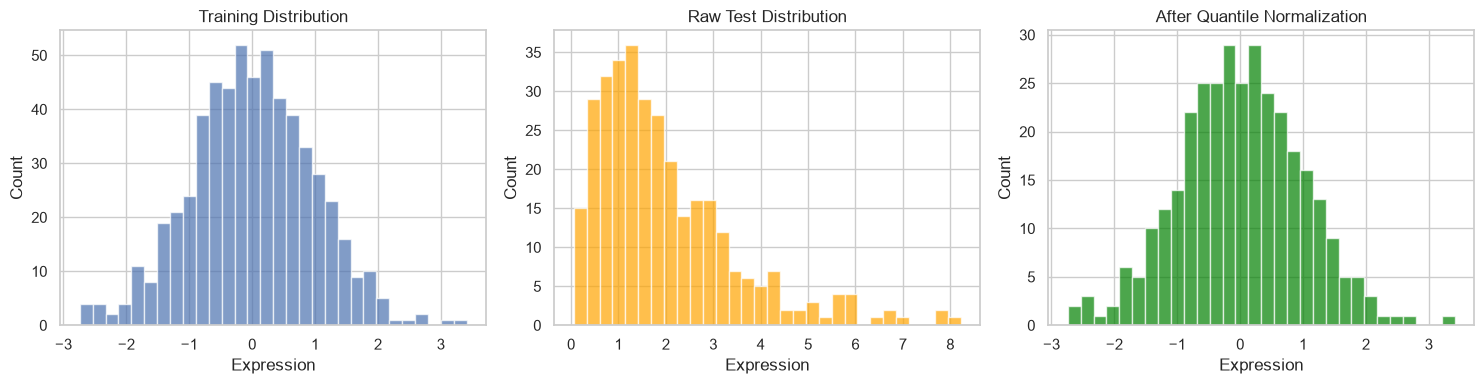

In [5]:
from scipy.interpolate import interp1d

def quantile_normalize(ref, target):
    ref_sorted = np.sort(ref.dropna())
    ranks = np.argsort(np.argsort(target.values))
    pcts = np.linspace(0, 1, len(ref_sorted))
    f = interp1d(pcts, ref_sorted, kind='linear', fill_value='extrapolate')
    return pd.Series(f(ranks / (len(target) - 1)), index=target.index)

x = np.random.normal(0, 1, 585)
y = np.random.gamma(2, 1, 329)
y_qnorm = quantile_normalize(pd.Series(x), pd.Series(y))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(x, bins=30, alpha=0.7, label='Training (RNA-seq)')
axes[0].set_title('Training Distribution')
axes[1].hist(y, bins=30, alpha=0.7, color='orange', label='Test (Microarray)')
axes[1].set_title('Raw Test Distribution')
axes[2].hist(y_qnorm, bins=30, alpha=0.7, color='green', label='QN Test')
axes[2].set_title('After Quantile Normalization')
for ax in axes: ax.set_xlabel('Expression'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

---
## Step 5: Run Full Preprocessing Pipeline

This saves processed `X_features.csv` and `y_target.csv` to `data/processed/`.

In [6]:
X, y_out = preprocess_and_save_data(expr_df, clinical_df, output_dir='../data/processed')
print(f'Final features: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Target classes: {y_out.value_counts().to_dict()}')
print(f'\nSaved files:')
import os
for f in os.listdir('../data/processed'):
    print(f'  {f} ({os.path.getsize(f"../data/processed/{f}")/1024:.1f} KB)')

Computing score from 10/10 available genes.
Binarizing target at median: -0.0281
Matched 585 samples.
No proliferation genes found in features.
Leakage check passed. Features: 22185 columns.


Saved dataset: X=(585, 22185), y=(585,)
Final features: 585 samples, 22185 features
Target classes: {1: 293, 0: 292}

Saved files:
  clinical.csv (91.3 KB)
  cptac_clinical.csv (15.8 KB)
  cptac_proliferation_scores.csv (3.0 KB)
  cptac_X_features.csv (25923.4 KB)
  cptac_y_target.csv (1.1 KB)
  geo17538_clinical.csv (17.7 KB)
  geo17538_proliferation_scores.csv (7.2 KB)
  geo17538_X_features.csv (69460.9 KB)
  geo17538_y_target.csv (3.0 KB)
  geo_clinical.csv (99.6 KB)
  geo_pan_clinical.csv (115.5 KB)
  geo_pan_proliferation_scores.csv (24.7 KB)
  geo_pan_X_features.csv (239786.9 KB)
  geo_pan_y_target.csv (10.5 KB)
  geo_proliferation_scores.csv (17.6 KB)
  geo_X_features.csv (170505.2 KB)
  geo_y_target.csv (7.5 KB)
  proliferation_scores.csv (17.8 KB)
  synthetic_clinical.csv (14.1 KB)
  synthetic_proliferation_scores.csv (9.2 KB)
  synthetic_X_features.csv (10543.0 KB)
  synthetic_y_target.csv (4.0 KB)
  tcga_clinical.csv (318.0 KB)
  tcga_pan_clinical.csv (429.6 KB)
  tcga_pan_p

---
## Preprocessing Summary

| Step | Description | ISEF Relevance |
|------|-------------|----------------|
| 1. Proliferation score | Mean z-score of 10 cell-cycle genes | Novel target definition |
| 2. Target binarization | Median split -> High/Low | Enables classification |
| 3. Gene removal | Delete 10 genes from features | **Target leakage prevention** |
| 4. Clinical encoding | One-hot stage, label sex | Multimodal feature integration |
| 5. QN alignment | Match test dist to train dist | **Cross-platform CS contribution** |

Next: model training with nested cross-validation (notebook 03).